# Calculation general flare distributions in viewing angle $\mu$

Load dependicies

In [3]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Specificy the overall 3D-distribution for active regions and flares on a star (here we used the fit of experimental_flare_distribuition.ipynb of the Sun). 
We assume this only depends upon the lattitude $\alpha$.

In [4]:
# general distribution for area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)

def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit) / 2 / np.pi / (np.sin(alpha) + err) / 2 
            # fit of dist when integrated over phi and absolute value so accounting for that

display the distribution as a function of lattitude $\alpha$

Text(0.5, 1.0, 'Distribution of ')

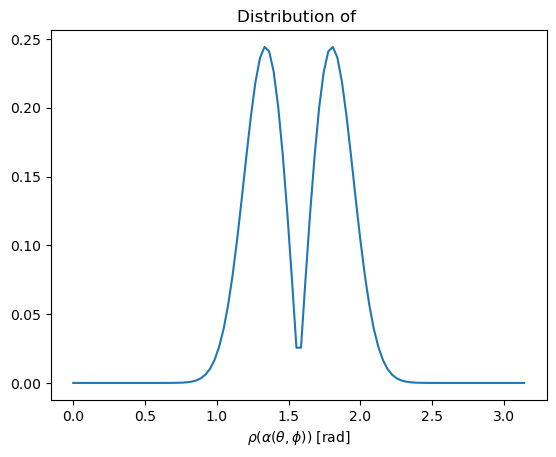

In [5]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.xlabel(r"$\alpha(\theta, \phi)$ [rad]")
plt.xlabel(r"$\rho(\alpha(\theta, \phi))$ [rad]")
plt.title('Distribution of ')

In [6]:
# f = lambda x: rice_dist(x, sigma_fit, nu_fit)


# quad(f,0, np.pi)

Therefore density as a function of $\mu$ is $$\rho_\mu(\mu) = 2 \int_{[0, 2\pi]}d\phi \rho (\alpha(\theta, \phi))
.$$
where
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$. (For all symbols we refer to the associated paper.)

We now calculate the distribution in $\mu$ for a given angle $\tau$

In [7]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

def rho_mu(mu, tau):
    theta = np.arccos(mu)
    I = lambda phi: rho(get_alpha(tau, theta, phi))
    return 2 * quad(I, 0, 2*np.pi)[0] 

def rho_mus(mus, tau):
    return [ rho_mu(mu,tau) for mu in mus]
    


0.0 (0.9896632430611714, 4.727765598241539e-14)
0.39269908169872414 (0.989663237218806, 9.637162925000425e-09)
0.7853981633974483 (0.9896632413563907, 4.110435339370042e-09)
1.1780972450961724 (0.9896632373627069, 1.0451195036800443e-09)
1.5707963267948966 (0.9896632430612415, 5.93999038844828e-09)


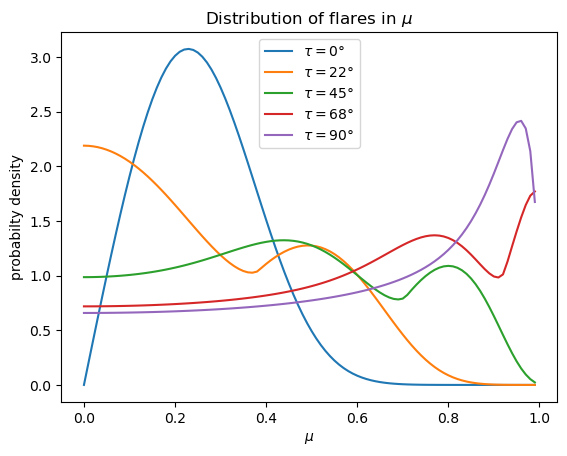

In [8]:
rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

# def rho_mus2(mus, tau):
#     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

mu = np.linspace(0,0.99, 100)

for tau in np.linspace(0,np.pi/2, 5):
    plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
    print(tau, quad(rho_mu_of_tau(tau), 0, 1))

# plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

# Smearing out by height of flare


In [ ]:
# give flare height as a fraction of stellar/solar radius
h = 0.01
tau = np.pi/2
mu = np.linspace(0,1, 10000)

rhoold = rho_mus(mu, tau)
eps = 0.015

def new_mu(h,mu):
    x2 = (1+h) * np.abs((1 - mu**2))**.5
    if x2 >= 1:
        return 0
    return (1 - x2**2)**.5

def new_density(mu, rhoold, h, eps):
    rhonew = np.zeros(len(mu))
    for i,rh in enumerate(rhoold):
        i = mu[i]
        i2 = new_mu(h, i)
        muaff = np.where(mu < i + eps/2, np.where(mu > i2 - eps/2, 1, 0), 0) + np.where(mu > 2-i - eps / 2, np.where(mu < 2 - i2 + eps/2, 1, 0), 0)
        rhonew += muaff * rh / np.sum(muaff)
    return rhonew / np.sum(rhonew) * len(mu)

rho2 = new_density(mu, rhoold, h, eps)


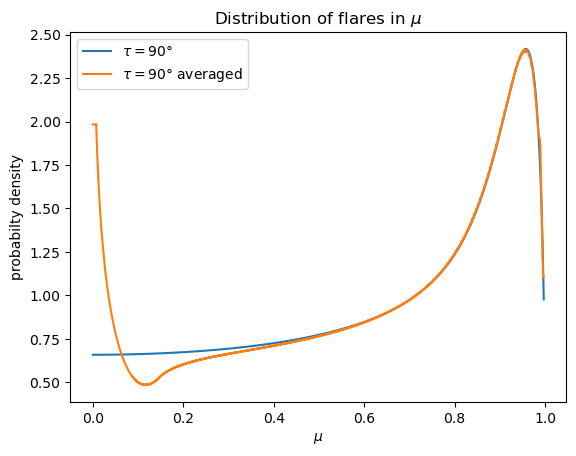

In [58]:

plt.plot(mu, rhoold, label=fr'$\tau=${round(tau*180/np.pi)}°')
plt.plot(mu, rho2, label=fr'$\tau=${round(tau*180/np.pi)}° averaged')
# plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

# tau = 74 degrees but with symmetry around $\mu=1$

In [63]:
# give flare height as a fraction of stellar/solar radius
h = 0.01
tau = 74/180 *np.pi
mu = np.linspace(0,1, 10000)
rhoold = rho_mus(mu, tau)
eps = 0.015

def new_mu(h,mu):
    x2 = (1+h) * np.abs((1 - mu**2))**.5
    if x2 >= 1:
        return 0
    return (1 - x2**2)**.5

def new_density(mu, rhoold, h, eps):
    rhonew = np.zeros(len(mu))
    for i,rh in enumerate(rhoold):
        i = mu[i]
        i2 = new_mu(h, i)
        muaff = np.where(mu < i + eps/2, np.where(mu > i2 - eps/2, 1, 0), 0) + np.where(mu > 2-i - eps / 2, np.where(mu < 2 - i2 + eps/2, 1, 0), 0)
        rhonew += muaff * rh / np.sum(muaff)
    return rhonew / np.sum(rhonew) * len(mu)

rho2 = new_density(mu, rhoold, h, eps)


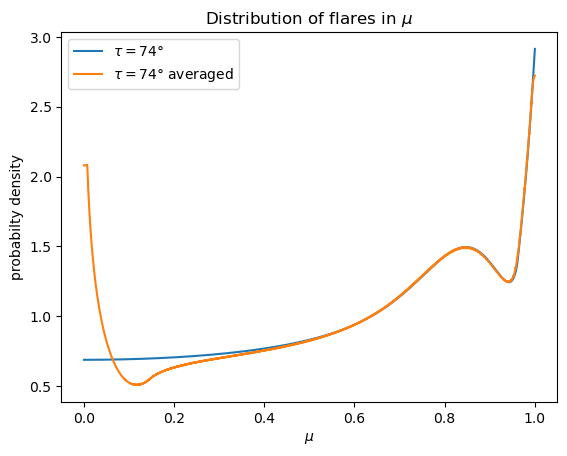

In [64]:

plt.plot(mu, rhoold, label=fr'$\tau=${round(tau*180/np.pi)}°')
plt.plot(mu, rho2, label=fr'$\tau=${round(tau*180/np.pi)}° averaged')
# plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

# Smearing out by height of flare, not correcting for transparancy one obtains


In [19]:
# give flare height as a fraction of stellar/solar radius
h = 0.01
tau = np.pi/2
mu = np.linspace(0,0.99, 500)

rhoold = rho_mus(mu, tau)
eps = 0.05

def new_mu(h,mu):
    x2 = (1+h) * np.abs((1 - mu**2))**.5
    if x2 >= 1:
        return 0
    return (1 - x2**2)**.5

def new_density(mu, rhoold, h, eps):
    rhonew = np.zeros(len(mu))
    for i,rh in enumerate(rhoold):
        i = mu[i]
        i2 = new_mu(h, i)
        muaff = np.where(mu < i + eps, np.where(mu > i2 - eps, 1, 0), 0)
        rhonew += muaff * rh #/ np.sum(muaff)
    return rhonew / np.sum(rhonew) * len(mu)

rho2 = new_density(mu, rhoold, h, eps)


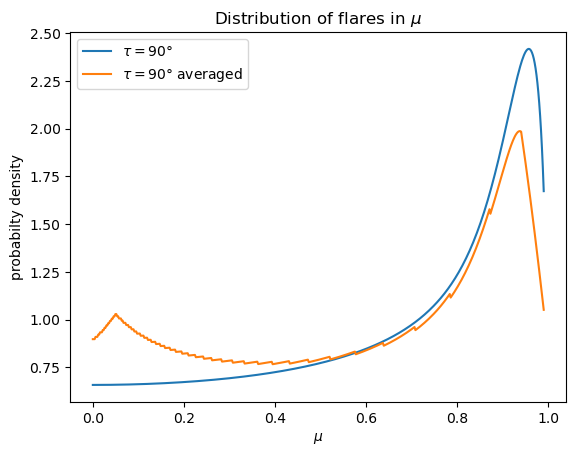

In [20]:

plt.plot(mu, rhoold, label=fr'$\tau=${round(tau*180/np.pi)}°')
plt.plot(mu, rho2, label=fr'$\tau=${round(tau*180/np.pi)}° averaged')
# plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()